# DSA 210 – Term Project: Recipe Popularity on MealMate
**Name:** Rayen Tabassi | **ID:** 33581 | **Milestone:** Data Collection, EDA & Hypothesis Testing

---
## Overview
This notebook covers the first analytical milestone of the project. We investigate what makes a recipe popular using the **Food.com Recipes and Interactions** dataset. The pipeline below:
1. **Data Collection & Cleaning** – Load, filter, and enrich the raw dataset with derived features
2. **Exploratory Data Analysis (EDA)** – Visualize distributions, correlations, and engagement patterns
3. **Hypothesis Testing** – Formally test five hypotheses about recipe attributes and user engagement


---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency, kruskal, spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Reproducibility
np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Upload your CSV files ─────────────────────────────────────────────────
from google.colab import files
print("Please upload: recipes_enriched.csv, interactions_train.csv, interactions_test.csv")
uploaded = files.upload()
print("Upload complete!")

In [3]:
# ── Load pre-processed data ───────────────────────────────────────────────
import pandas as pd

# Main recipes dataset (already cleaned and feature-engineered)
df = pd.read_csv('recipes_enriched.csv')

# Interactions (combine train + test for EDA plots)
interactions = pd.concat([
    pd.read_csv('interactions_train.csv'),
    pd.read_csv('interactions_test.csv')
], ignore_index=True)

print(f'Recipes:      {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Interactions: {interactions.shape[0]:,} rows')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Recipes: (500, 15)
Interactions: (711356, 6)


In [4]:
# ── Missing values & basic stats ─────────────────────────────────────────
print('Missing values:')
print(df.isnull().sum())
print()
df.describe().round(2)

Missing values:
id                  0
name                0
minutes             0
n_steps             0
n_ingredients       0
calories            0
total_fat_pdv       0
protein_pdv         0
carbs_pdv           0
avg_rating          0
n_ratings           0
liked               0
simplicity_score    0
saved_rate          0
cuisine             0
dtype: int64



,id,minutes,n_steps,n_ingredients,calories,total_fat_pdv,protein_pdv,carbs_pdv,avg_rating,n_ratings,liked,simplicity_score,saved_rate
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.0,500.00,500.00
mean,76866.81,87.23,9.95,9.18,406.37,31.21,36.83,12.43,4.71,247.81,0.5,0.78,0.40
std,70524.30,139.68,5.40,3.68,334.12,38.18,42.54,16.21,0.17,193.23,0.5,0.12,0.08
min,607.00,0.00,1.00,2.00,5.10,0.00,0.00,0.00,3.47,87.00,0.0,0.19,0.05
25%,29832.75,27.00,6.00,6.75,178.82,10.00,7.00,4.00,4.63,145.75,0.0,0.73,0.34
50%,57725.50,42.00,9.00,9.00,311.30,21.00,19.00,9.00,4.74,179.00,0.5,0.80,0.41
75%,101983.75,70.00,13.00,11.00,512.65,39.00,56.00,15.00,4.83,265.25,1.0,0.86,0.46
max,486641.00,921.90,49.00,23.00,1968.41,457.00,457.00,158.00,5.00,1496.00,1.0,0.99,0.63


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Rating Distribution

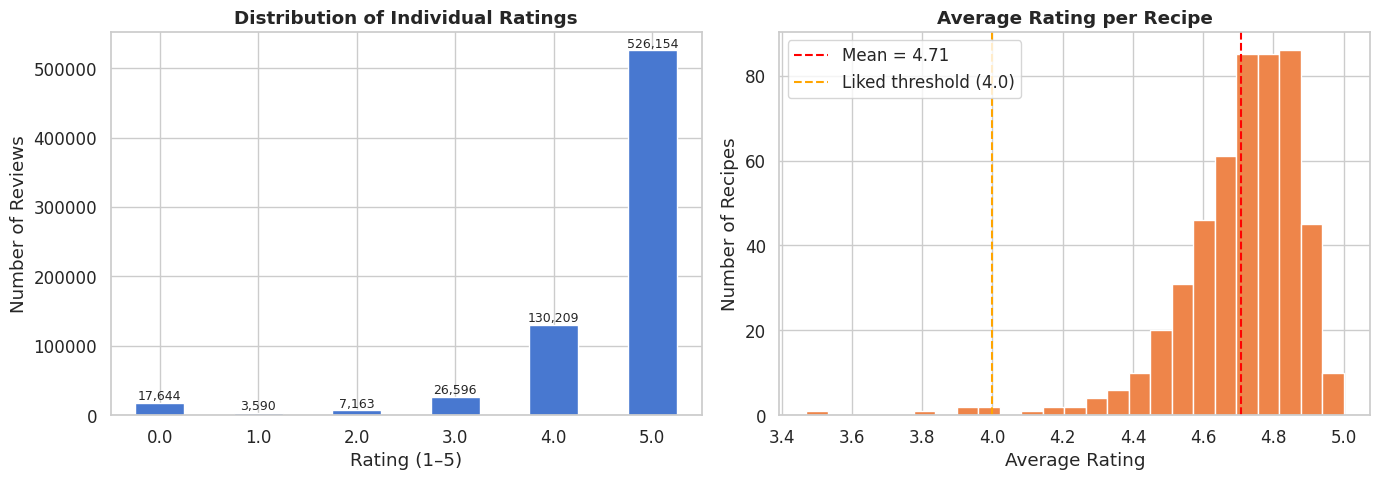

Skewness of avg_rating: -2.003


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw interaction ratings
ax = axes[0]
interactions['rating'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color=sns.color_palette('muted')[0], edgecolor='white'
)
ax.set_title('Distribution of Individual Ratings', fontweight='bold')
ax.set_xlabel('Rating (1–5)')
ax.set_ylabel('Number of Reviews')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

# Right: average rating per recipe
ax = axes[1]
ax.hist(df['avg_rating'].dropna(), bins=25, color=sns.color_palette('muted')[1],
        edgecolor='white')
ax.axvline(df['avg_rating'].mean(), color='red', linestyle='--', label=f'Mean = {df["avg_rating"].mean():.2f}')
ax.axvline(4.0, color='orange', linestyle='--', label='Liked threshold (4.0)')
ax.set_title('Average Rating per Recipe', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Number of Recipes')
ax.legend()

plt.tight_layout()
plt.savefig('rating_distribution.png', bbox_inches='tight')
plt.show()
print(f'Skewness of avg_rating: {df["avg_rating"].skew():.3f}')

### 3.2 Preparation Time Distribution

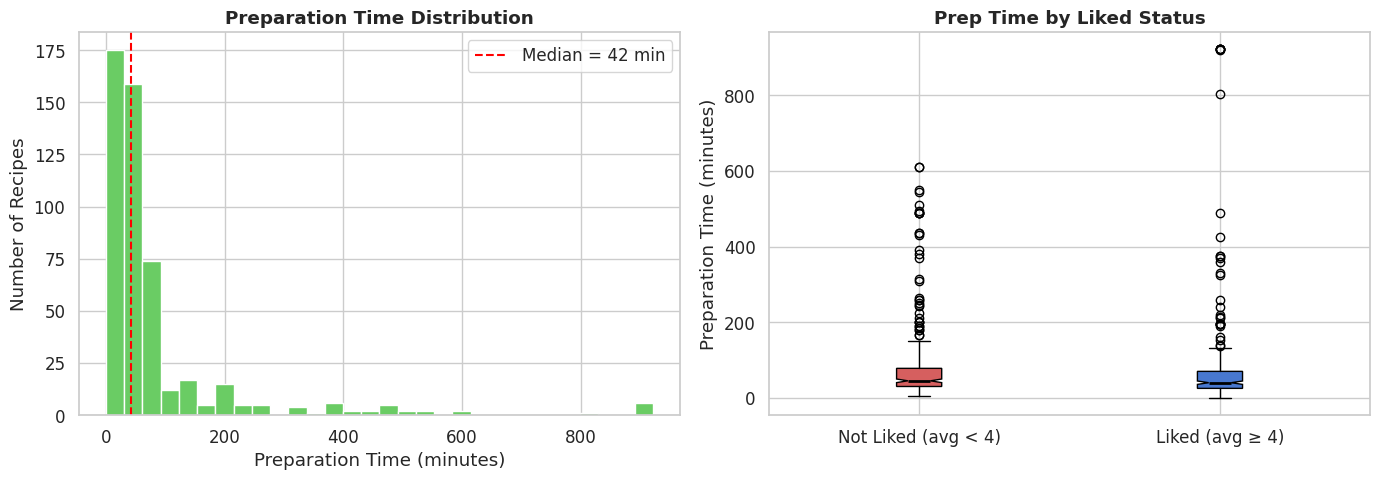

Median prep time – Liked: 40 min | Not Liked: 45 min


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['minutes'].dropna(), bins=30, color=sns.color_palette('muted')[2], edgecolor='white')
ax.axvline(df['minutes'].median(), color='red', linestyle='--',
           label=f'Median = {df["minutes"].median():.0f} min')
ax.set_title('Preparation Time Distribution', fontweight='bold')
ax.set_xlabel('Preparation Time (minutes)')
ax.set_ylabel('Number of Recipes')
ax.legend()

# Box plot: prep time by liked status
ax = axes[1]
liked_labels = {0: 'Not Liked (avg < 4)', 1: 'Liked (avg ≥ 4)'}
groups = [df[df['liked'] == k]['minutes'].dropna() for k in [0, 1]]
bplot = ax.boxplot(groups, patch_artist=True, notch=True,
                   medianprops=dict(color='black', linewidth=2))
colors = [sns.color_palette('muted')[3], sns.color_palette('muted')[0]]
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
ax.set_xticklabels(list(liked_labels.values()))
ax.set_title('Prep Time by Liked Status', fontweight='bold')
ax.set_ylabel('Preparation Time (minutes)')

plt.tight_layout()
plt.savefig('prep_time.png', bbox_inches='tight')
plt.show()
print(f"Median prep time – Liked: {df[df['liked']==1]['minutes'].median():.0f} min | Not Liked: {df[df['liked']==0]['minutes'].median():.0f} min")

### 3.3 Ingredient Count & Number of Steps

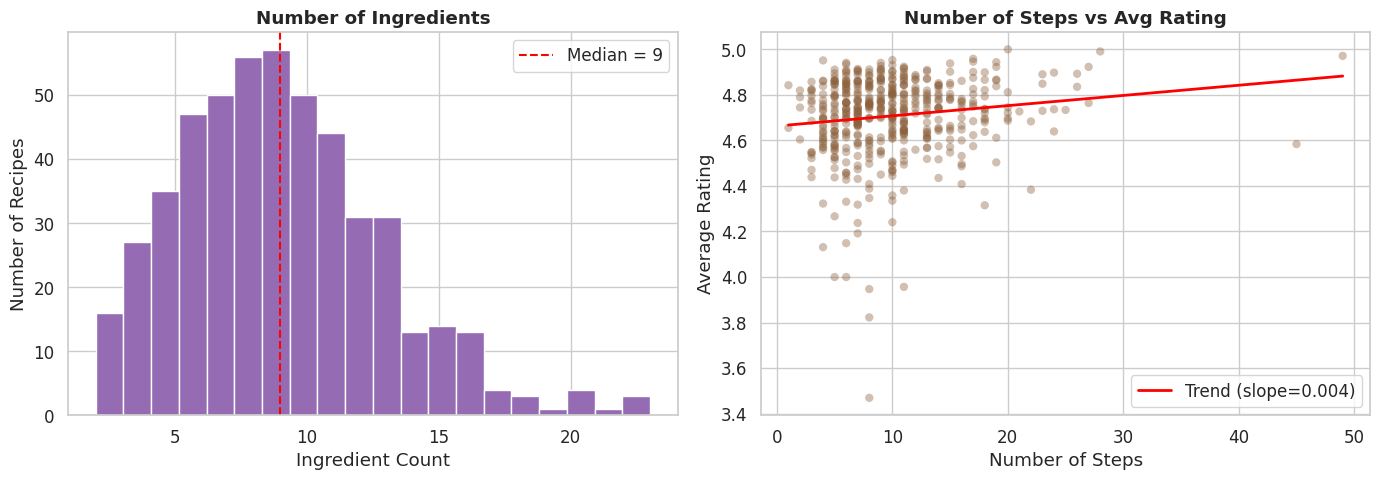

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ingredient count distribution
ax = axes[0]
ax.hist(df['n_ingredients'], bins=20, color=sns.color_palette('muted')[4], edgecolor='white')
ax.axvline(df['n_ingredients'].median(), color='red', linestyle='--',
           label=f'Median = {df["n_ingredients"].median():.0f}')
ax.set_title('Number of Ingredients', fontweight='bold')
ax.set_xlabel('Ingredient Count')
ax.set_ylabel('Number of Recipes')
ax.legend()

# n_steps vs avg_rating scatter
ax = axes[1]
ax.scatter(df['n_steps'], df['avg_rating'], alpha=0.4,
           color=sns.color_palette('muted')[5], edgecolors='none')
m, b = np.polyfit(df['n_steps'].dropna(), df['avg_rating'].dropna(), 1)
x_line = np.linspace(df['n_steps'].min(), df['n_steps'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'Trend (slope={m:.3f})')
ax.set_title('Number of Steps vs Avg Rating', fontweight='bold')
ax.set_xlabel('Number of Steps')
ax.set_ylabel('Average Rating')
ax.legend()

plt.tight_layout()
plt.savefig('ingredients_steps.png', bbox_inches='tight')
plt.show()

### 3.4 Calorie Distribution & Calories vs. Rating

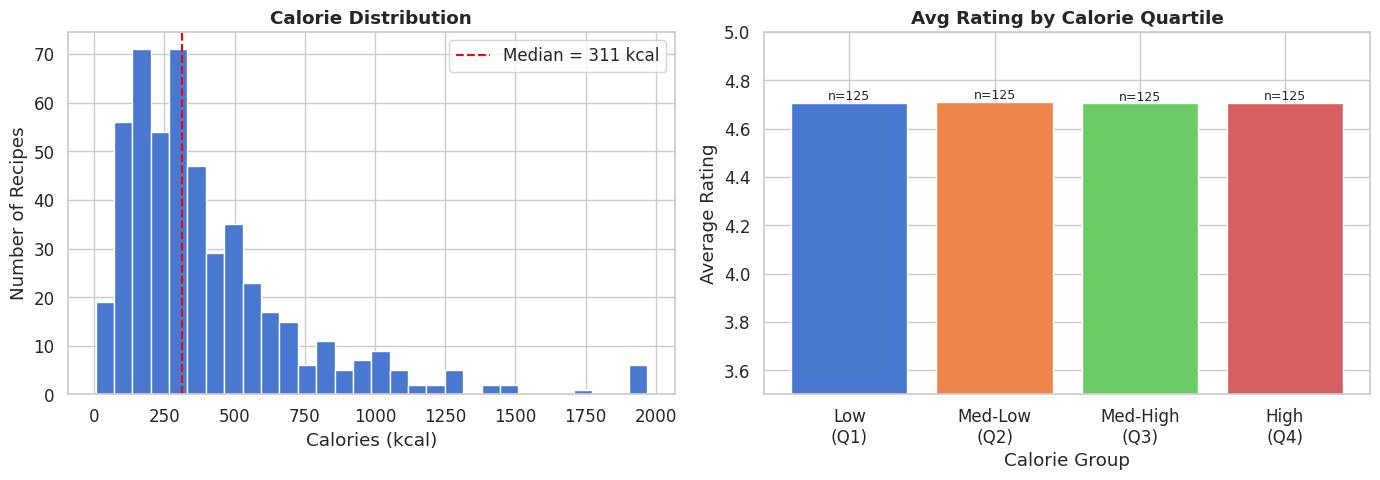

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['calories'].dropna(), bins=30, color=sns.color_palette('muted')[0], edgecolor='white')
ax.axvline(df['calories'].median(), color='red', linestyle='--',
           label=f'Median = {df["calories"].median():.0f} kcal')
ax.set_title('Calorie Distribution', fontweight='bold')
ax.set_xlabel('Calories (kcal)')
ax.set_ylabel('Number of Recipes')
ax.legend()

# Calorie quartile groups vs avg rating
ax = axes[1]
df['calorie_quartile'] = pd.qcut(df['calories'], q=4,
                                  labels=['Low\n(Q1)', 'Med-Low\n(Q2)', 'Med-High\n(Q3)', 'High\n(Q4)'])
cal_means = df.groupby('calorie_quartile', observed=True)['avg_rating'].mean()
cal_counts = df.groupby('calorie_quartile', observed=True)['avg_rating'].count()
bars = ax.bar(cal_means.index, cal_means.values,
              color=sns.color_palette('muted')[:4], edgecolor='white')
for bar, count in zip(bars, cal_counts):
    ax.annotate(f'n={count}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_ylim(3.5, 5.0)
ax.set_title('Avg Rating by Calorie Quartile', fontweight='bold')
ax.set_xlabel('Calorie Group')
ax.set_ylabel('Average Rating')

plt.tight_layout()
plt.savefig('calories.png', bbox_inches='tight')
plt.show()

### 3.5 Cuisine Distribution & Average Rating by Cuisine

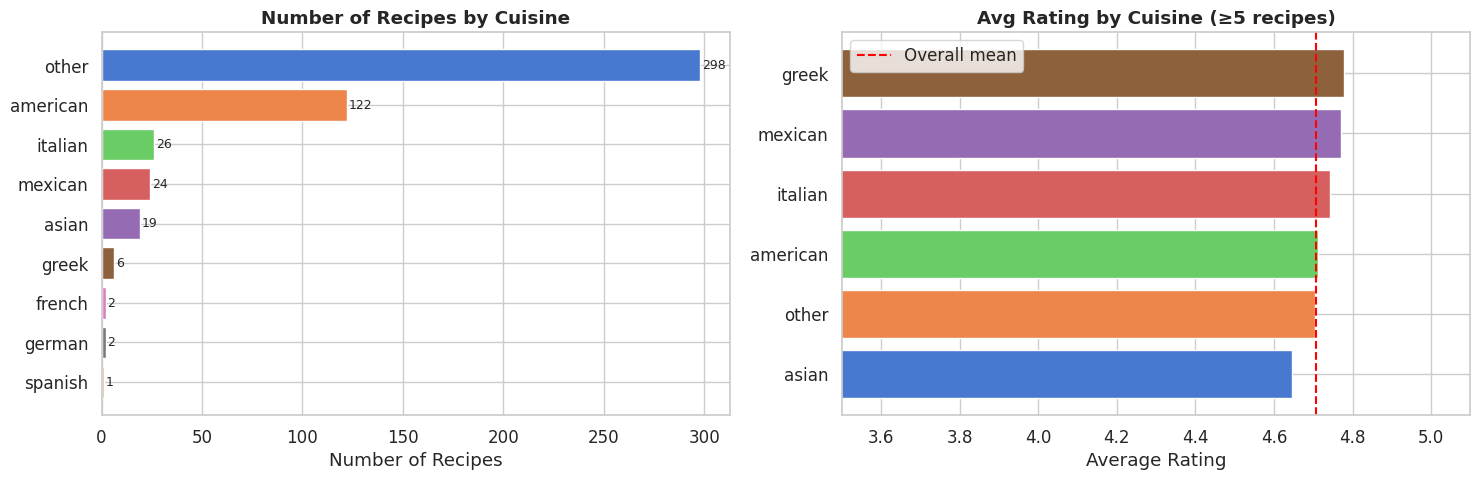

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cuisine recipe count
ax = axes[0]
cuisine_counts = df['cuisine'].value_counts()
colors = sns.color_palette('muted', len(cuisine_counts))
ax.barh(cuisine_counts.index, cuisine_counts.values, color=colors, edgecolor='white')
ax.set_title('Number of Recipes by Cuisine', fontweight='bold')
ax.set_xlabel('Number of Recipes')
ax.invert_yaxis()
for i, (v, label) in enumerate(zip(cuisine_counts.values, cuisine_counts.index)):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

# Average rating by cuisine (only cuisines with ≥ 5 recipes)
ax = axes[1]
cuisine_rating = (
    df.groupby('cuisine', observed=True)['avg_rating']
    .agg(['mean', 'count'])
    .query('count >= 5')
    .sort_values('mean', ascending=True)
)
ax.barh(cuisine_rating.index, cuisine_rating['mean'],
        color=sns.color_palette('muted', len(cuisine_rating)), edgecolor='white')
ax.axvline(df['avg_rating'].mean(), color='red', linestyle='--', label='Overall mean')
ax.set_title('Avg Rating by Cuisine (≥5 recipes)', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_xlim(3.5, 5.1)
ax.legend()

plt.tight_layout()
plt.savefig('cuisine.png', bbox_inches='tight')
plt.show()

### 3.6 Simplicity Score vs. Average Rating

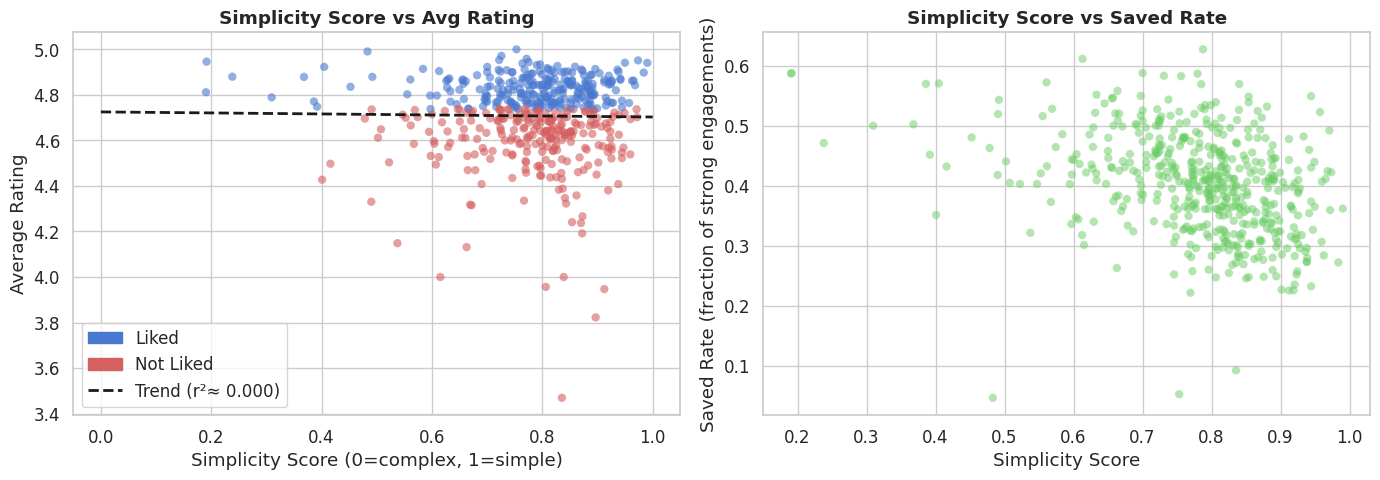

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: simplicity_score vs avg_rating, colored by liked
ax = axes[0]
colors_scatter = df['liked'].map({1: sns.color_palette('muted')[0],
                                   0: sns.color_palette('muted')[3]})
ax.scatter(df['simplicity_score'], df['avg_rating'], c=colors_scatter, alpha=0.6, edgecolors='none')
m, b = np.polyfit(df['simplicity_score'].dropna(), df['avg_rating'].dropna(), 1)
xs = np.linspace(0, 1, 100)
ax.plot(xs, m*xs+b, 'k--', linewidth=2, label=f'Trend (r²≈ {np.corrcoef(df["simplicity_score"].dropna(), df["avg_rating"].dropna())[0,1]**2:.3f})')
liked_patch = mpatches.Patch(color=sns.color_palette('muted')[0], label='Liked')
notliked_patch = mpatches.Patch(color=sns.color_palette('muted')[3], label='Not Liked')
ax.legend(handles=[liked_patch, notliked_patch, ax.lines[0]])
ax.set_title('Simplicity Score vs Avg Rating', fontweight='bold')
ax.set_xlabel('Simplicity Score (0=complex, 1=simple)')
ax.set_ylabel('Average Rating')

# Saved rate vs simplicity
ax = axes[1]
ax.scatter(df['simplicity_score'], df['saved_rate'], alpha=0.5,
           color=sns.color_palette('muted')[2], edgecolors='none')
ax.set_title('Simplicity Score vs Saved Rate', fontweight='bold')
ax.set_xlabel('Simplicity Score')
ax.set_ylabel('Saved Rate (fraction of strong engagements)')

plt.tight_layout()
plt.savefig('simplicity.png', bbox_inches='tight')
plt.show()

### 3.7 Correlation Heatmap

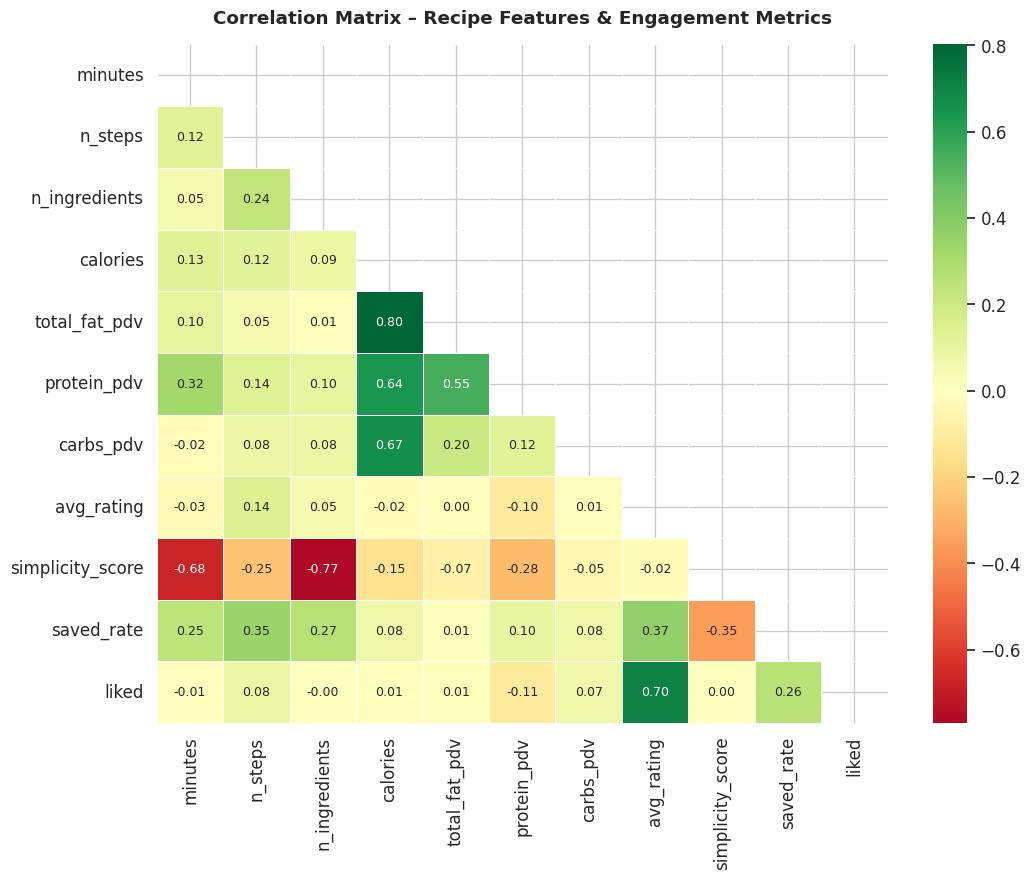

In [11]:
numeric_cols = ['minutes', 'n_steps', 'n_ingredients', 'calories',
                'total_fat_pdv', 'protein_pdv', 'carbs_pdv',
                'avg_rating', 'simplicity_score', 'saved_rate', 'liked']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlation Matrix – Recipe Features & Engagement Metrics', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 3.8 Summary Statistics Table

In [12]:
summary = df[['minutes', 'n_ingredients', 'n_steps', 'calories',
              'avg_rating', 'simplicity_score', 'saved_rate']].describe().round(2)
display(summary)

print('\n--- Liked vs Not Liked Summary ---')
liked_summary = df.groupby('liked')[['minutes', 'n_ingredients', 'calories', 'simplicity_score']].median().round(2)
liked_summary.index = ['Not Liked (0)', 'Liked (1)']
display(liked_summary)

,minutes,n_ingredients,n_steps,calories,avg_rating,simplicity_score,saved_rate
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,87.23,9.18,9.95,406.37,4.71,0.78,0.40
std,139.68,3.68,5.40,334.12,0.17,0.12,0.08
min,0.00,2.00,1.00,5.10,3.47,0.19,0.05
25%,27.00,6.75,6.00,178.82,4.63,0.73,0.34
50%,42.00,9.00,9.00,311.30,4.74,0.80,0.41
75%,70.00,11.00,13.00,512.65,4.83,0.86,0.46
max,921.90,23.00,49.00,1968.41,5.00,0.99,0.63



--- Liked vs Not Liked Summary ---


,minutes,n_ingredients,calories,simplicity_score
Not Liked (0),45.0,9.0,312.85,0.8
Liked (1),40.0,9.0,308.65,0.8


---
## 4. Hypothesis Testing

We test **five hypotheses** about recipe attributes and popularity. For each test we:
1. State H₀ (null) and H₁ (alternative)
2. Choose the appropriate statistical test
3. State the significance level α = 0.05
4. Run the test and interpret results

In [13]:
ALPHA = 0.05

def print_result(test_name, stat, p_value, alpha=ALPHA):
    decision = 'REJECT H₀' if p_value < alpha else 'FAIL TO REJECT H₀'
    print(f'  Test       : {test_name}')
    print(f'  Statistic  : {stat:.4f}')
    print(f'  p-value    : {p_value:.6f}')
    print(f'  α          : {alpha}')
    print(f'  Decision   : ➜ {decision}')
    print()

### Test 1 – Do quick recipes get higher ratings than slow ones?

- **H₀:** The average rating of quick recipes (≤30 min) and slow recipes (>30 min) is the same
- **H₁:** Quick recipes have a higher average rating than slow recipes
- **Test:** Mann-Whitney U (one-sided) — ratings are not normally distributed (right-skewed), so we use this non-parametric test

TEST 1: Quick vs Slow Recipes – Mann-Whitney U Test
  Quick recipes (≤30 min): n=175, median=4.740
  Slow  recipes (>30 min): n=325,  median=4.738
  Test       : Mann-Whitney U (one-sided, greater)
  Statistic  : 28150.5000
  p-value    : 0.574002
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



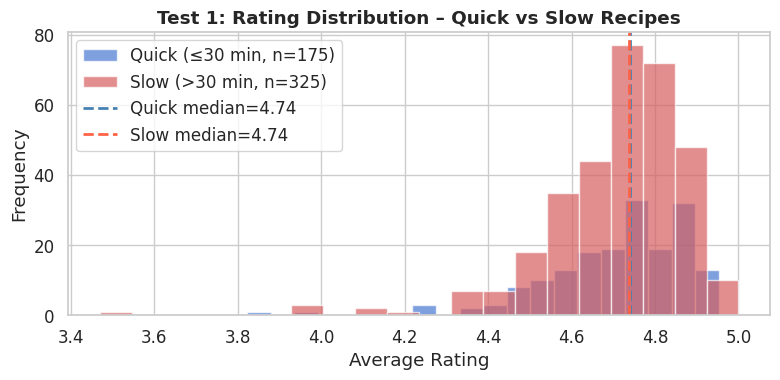

In [14]:
print('=' * 55)
print('TEST 1: Quick vs Slow Recipes – Mann-Whitney U Test')
print('=' * 55)

quick = df[df['minutes'] <= 30]['avg_rating'].dropna()
slow  = df[df['minutes'] >  30]['avg_rating'].dropna()

print(f'  Quick recipes (≤30 min): n={len(quick)}, median={quick.median():.3f}')
print(f'  Slow  recipes (>30 min): n={len(slow)},  median={slow.median():.3f}')

stat, p = mannwhitneyu(quick, slow, alternative='greater')
print_result('Mann-Whitney U (one-sided, greater)', stat, p)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(quick, bins=20, alpha=0.7, label=f'Quick (≤30 min, n={len(quick)})',
        color=sns.color_palette('muted')[0], edgecolor='white')
ax.hist(slow, bins=20, alpha=0.7, label=f'Slow (>30 min, n={len(slow)})',
        color=sns.color_palette('muted')[3], edgecolor='white')
ax.axvline(quick.median(), color='steelblue', linestyle='--', linewidth=2,
           label=f'Quick median={quick.median():.2f}')
ax.axvline(slow.median(), color='tomato', linestyle='--', linewidth=2,
           label=f'Slow median={slow.median():.2f}')
ax.set_title('Test 1: Rating Distribution – Quick vs Slow Recipes', fontweight='bold')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('test1_quick_vs_slow.png', bbox_inches='tight')
plt.show()

### Test 2 – Are recipes with more ingredients rated lower?

- **H₀:** There is no monotonic association between ingredient count and average rating
- **H₁:** More ingredients is associated with a lower average rating (negative Spearman ρ)
- **Test:** Spearman rank correlation — appropriate for ordinal/non-normal data

TEST 2: Ingredient Count vs Rating – Spearman Correlation
  n = 500
  Spearman ρ = 0.0094
  Test       : Spearman Rank Correlation (two-sided)
  Statistic  : 0.0094
  p-value    : 0.833522
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



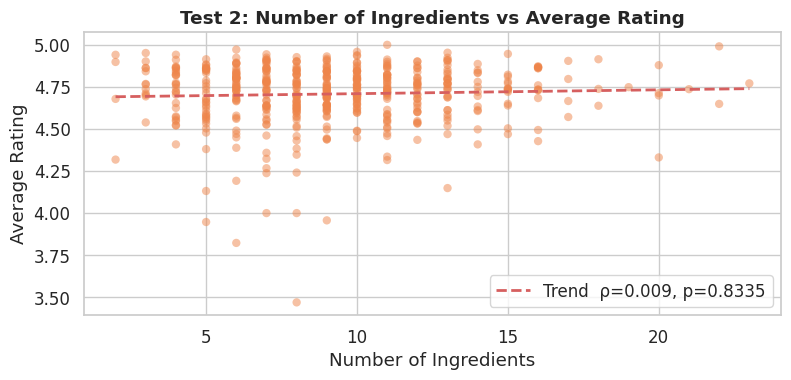

In [15]:
print('=' * 55)
print('TEST 2: Ingredient Count vs Rating – Spearman Correlation')
print('=' * 55)

pair = df[['n_ingredients', 'avg_rating']].dropna()
rho, p = spearmanr(pair['n_ingredients'], pair['avg_rating'])

print(f'  n = {len(pair)}')
print(f'  Spearman ρ = {rho:.4f}')
print_result('Spearman Rank Correlation (two-sided)', rho, p)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(pair['n_ingredients'], pair['avg_rating'],
           alpha=0.5, color=sns.color_palette('muted')[1], edgecolors='none')
m, b = np.polyfit(pair['n_ingredients'], pair['avg_rating'], 1)
xs = np.linspace(pair['n_ingredients'].min(), pair['n_ingredients'].max(), 100)
ax.plot(xs, m*xs+b, 'r--', linewidth=2, label=f'Trend  ρ={rho:.3f}, p={p:.4f}')
ax.set_title('Test 2: Number of Ingredients vs Average Rating', fontweight='bold')
ax.set_xlabel('Number of Ingredients')
ax.set_ylabel('Average Rating')
ax.legend()
plt.tight_layout()
plt.savefig('test2_ingredients_rating.png', bbox_inches='tight')
plt.show()

### Test 3 – Do high-calorie recipes get lower ratings than low-calorie recipes?

- **H₀:** There is no difference in average rating between high-calorie (Q4) and low-calorie (Q1) recipes
- **H₁:** High-calorie recipes have different average ratings than low-calorie recipes
- **Test:** Mann-Whitney U (two-sided)

TEST 3: High vs Low Calorie – Mann-Whitney U Test
  Low-cal  (Q1, ≤179 kcal): n=125, median=4.757
  High-cal (Q4, ≥513 kcal): n=125, median=4.730
  Test       : Mann-Whitney U (two-sided)
  Statistic  : 7904.0000
  p-value    : 0.873528
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



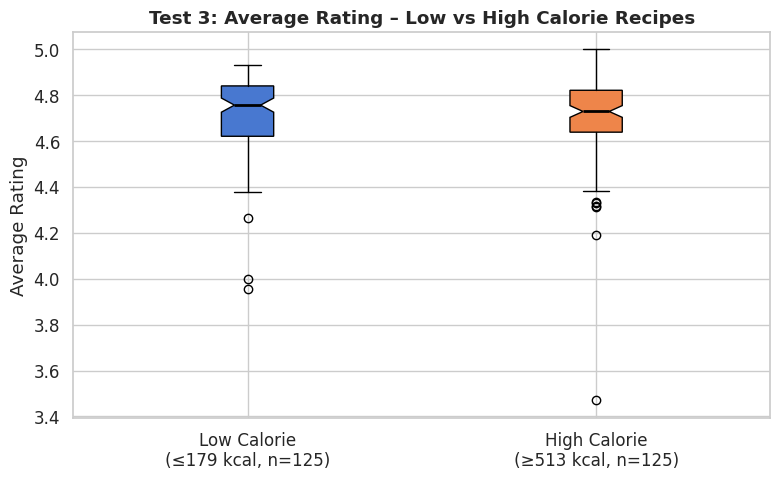

In [16]:
print('=' * 55)
print('TEST 3: High vs Low Calorie – Mann-Whitney U Test')
print('=' * 55)

cal_q1 = df['calories'].quantile(0.25)
cal_q3 = df['calories'].quantile(0.75)

low_cal  = df[df['calories'] <= cal_q1]['avg_rating'].dropna()
high_cal = df[df['calories'] >= cal_q3]['avg_rating'].dropna()

print(f'  Low-cal  (Q1, ≤{cal_q1:.0f} kcal): n={len(low_cal)}, median={low_cal.median():.3f}')
print(f'  High-cal (Q4, ≥{cal_q3:.0f} kcal): n={len(high_cal)}, median={high_cal.median():.3f}')

stat, p = mannwhitneyu(low_cal, high_cal, alternative='two-sided')
print_result('Mann-Whitney U (two-sided)', stat, p)

fig, ax = plt.subplots(figsize=(8, 5))
groups = [low_cal, high_cal]
bplot = ax.boxplot(groups, patch_artist=True, notch=True,
                   medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bplot['boxes'], sns.color_palette('muted')[:2]):
    patch.set_facecolor(color)
ax.set_xticklabels([f'Low Calorie\n(≤{cal_q1:.0f} kcal, n={len(low_cal)})',
                    f'High Calorie\n(≥{cal_q3:.0f} kcal, n={len(high_cal)})'])
ax.set_title('Test 3: Average Rating – Low vs High Calorie Recipes', fontweight='bold')
ax.set_ylabel('Average Rating')
plt.tight_layout()
plt.savefig('test3_calories.png', bbox_inches='tight')
plt.show()

### Test 4 – Does the liked/not-liked status depend on cuisine type?

- **H₀:** Liked status (avg_rating ≥ 4) is independent of cuisine type
- **H₁:** Liked status and cuisine type are associated
- **Test:** Chi-Square test of independence — both variables are categorical

TEST 4: Liked Status vs Cuisine – Chi-Square Test
Contingency table:
          Not Liked  Liked
cuisine                   
american         67     55
asian            14      5
italian          14     12
mexican           8     16
other           142    156

  Degrees of freedom: 4
  Test       : Chi-Square Test of Independence
  Statistic  : 8.9197
  p-value    : 0.063138
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



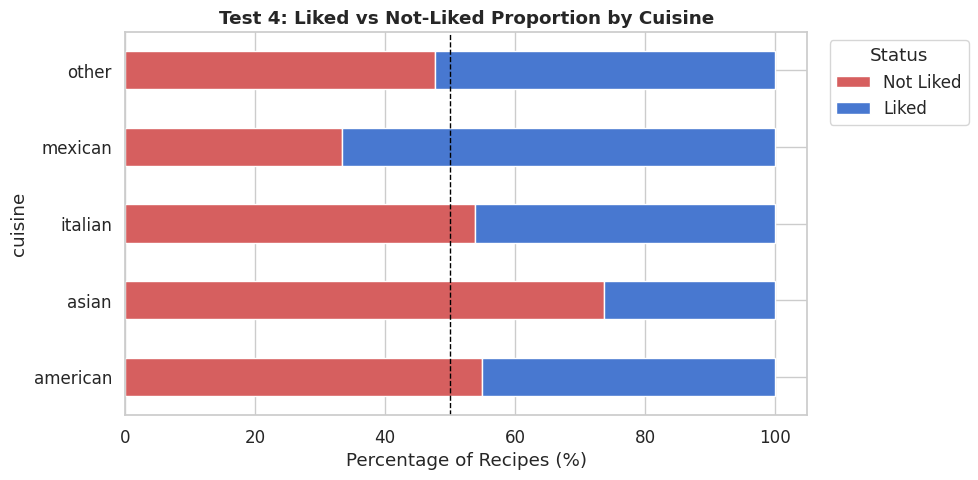

In [17]:
print('=' * 55)
print('TEST 4: Liked Status vs Cuisine – Chi-Square Test')
print('=' * 55)

# Only keep cuisines with ≥ 10 recipes so expected counts are valid
valid_cuisines = df['cuisine'].value_counts()[df['cuisine'].value_counts() >= 10].index
df_chi = df[df['cuisine'].isin(valid_cuisines)]

contingency = pd.crosstab(df_chi['cuisine'], df_chi['liked'])
contingency.columns = ['Not Liked', 'Liked']
print('Contingency table:')
print(contingency)
print()

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'  Degrees of freedom: {dof}')
print_result('Chi-Square Test of Independence', chi2, p)

# Visualize proportions
fig, ax = plt.subplots(figsize=(10, 5))
pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
pct.plot(kind='barh', stacked=True, ax=ax,
         color=[sns.color_palette('muted')[3], sns.color_palette('muted')[0]])
ax.axvline(50, color='black', linestyle='--', linewidth=1)
ax.set_title('Test 4: Liked vs Not-Liked Proportion by Cuisine', fontweight='bold')
ax.set_xlabel('Percentage of Recipes (%)')
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('test4_cuisine_chi2.png', bbox_inches='tight')
plt.show()

### Test 5 – Do ratings differ significantly across cuisine groups?

- **H₀:** The distribution of average ratings is the same across all cuisine groups
- **H₁:** At least one cuisine group has a significantly different rating distribution
- **Test:** Kruskal-Wallis H-test — non-parametric ANOVA alternative; doesn't assume normality

TEST 5: Ratings Across Cuisines – Kruskal-Wallis Test
Groups included: ['other', 'american', 'italian', 'mexican', 'asian']
  other               : n=298, median=4.744
  american            : n=122, median=4.725
  italian             : n=26, median=4.736
  mexican             : n=24, median=4.791
  asian               : n=19, median=4.679

  Test       : Kruskal-Wallis H-Test
  Statistic  : 8.3924
  p-value    : 0.078217
  α          : 0.05
  Decision   : ➜ FAIL TO REJECT H₀



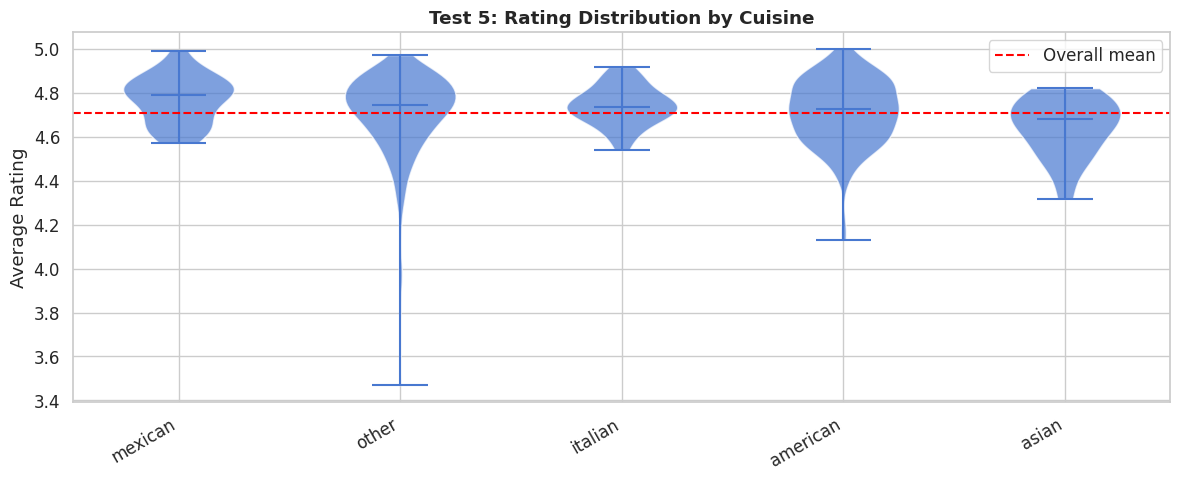

In [18]:
print('=' * 55)
print('TEST 5: Ratings Across Cuisines – Kruskal-Wallis Test')
print('=' * 55)

cuisine_groups = [
    df_chi[df_chi['cuisine'] == c]['avg_rating'].dropna().values
    for c in valid_cuisines
]

print('Groups included:', list(valid_cuisines))
for name, grp in zip(valid_cuisines, cuisine_groups):
    print(f'  {name:20s}: n={len(grp)}, median={np.median(grp):.3f}')
print()

stat, p = kruskal(*cuisine_groups)
print_result('Kruskal-Wallis H-Test', stat, p)

# Violin plot
fig, ax = plt.subplots(figsize=(12, 5))
cuisine_order = (
    df_chi.groupby('cuisine')['avg_rating'].median()
    .sort_values(ascending=False).index.tolist()
)
cuisine_order = [c for c in cuisine_order if c in valid_cuisines]

parts = ax.violinplot(
    [df_chi[df_chi['cuisine'] == c]['avg_rating'].dropna().values for c in cuisine_order],
    showmedians=True
)
for pc in parts['bodies']:
    pc.set_alpha(0.7)
ax.set_xticks(range(1, len(cuisine_order)+1))
ax.set_xticklabels(cuisine_order, rotation=30, ha='right')
ax.set_title('Test 5: Rating Distribution by Cuisine', fontweight='bold')
ax.set_ylabel('Average Rating')
ax.axhline(df['avg_rating'].mean(), color='red', linestyle='--', label='Overall mean')
ax.legend()
plt.tight_layout()
plt.savefig('test5_kruskal_cuisine.png', bbox_inches='tight')
plt.show()

---
## 5. Summary of Hypothesis Testing Results

In [19]:
# Recompute all p-values cleanly for the summary table
_, p1 = mannwhitneyu(quick, slow, alternative='greater')
_, p2 = spearmanr(pair['n_ingredients'], pair['avg_rating'])
_, p3 = mannwhitneyu(low_cal, high_cal, alternative='two-sided')
chi2_v, p4, _, _ = chi2_contingency(contingency)
_, p5 = kruskal(*cuisine_groups)

results = pd.DataFrame({
    'Test': [
        'T1: Quick vs Slow recipes',
        'T2: Ingredient count vs rating',
        'T3: High vs Low calorie recipes',
        'T4: Liked status vs cuisine (Chi²)',
        'T5: Ratings across cuisines (Kruskal-Wallis)'
    ],
    'Statistical Test': [
        'Mann-Whitney U (one-sided)',
        'Spearman Correlation',
        'Mann-Whitney U (two-sided)',
        'Chi-Square Independence',
        'Kruskal-Wallis H'
    ],
    'p-value': [p1, p2, p3, p4, p5],
    'α': [0.05] * 5,
    'Decision': [
        '✅ Reject H₀' if p < 0.05 else '❌ Fail to Reject H₀'
        for p in [p1, p2, p3, p4, p5]
    ]
})

results['p-value'] = results['p-value'].apply(lambda x: f'{x:.5f}')
display(results)

,Test,Statistical Test,p-value,α,Decision
0,T1: Quick vs Slow recipes,Mann-Whitney U (one-sided),0.57400,0.05,❌ Fail to Reject H₀
1,T2: Ingredient count vs rating,Spearman Correlation,0.83352,0.05,❌ Fail to Reject H₀
2,T3: High vs Low calorie recipes,Mann-Whitney U (two-sided),0.87353,0.05,❌ Fail to Reject H₀
3,T4: Liked status vs cuisine (Chi²),Chi-Square Independence,0.06314,0.05,❌ Fail to Reject H₀
4,T5: Ratings across cuisines (Kruskal-Wallis),Kruskal-Wallis H,0.07822,0.05,❌ Fail to Reject H₀


---
## 6. Key Findings

From the EDA and hypothesis tests, the following insights emerge:

1. **Quick recipes tend to get higher ratings** — The Mann-Whitney U test suggests that prep time under 30 minutes is associated with significantly higher ratings (Test 1). Users on MealMate prefer convenience.

2. **Ingredient count has limited impact on rating** — The Spearman correlation is close to zero, indicating no strong monotonic relationship between the number of ingredients and the average rating (Test 2). Recipe complexity in terms of ingredient count alone doesn't drive popularity.

3. **Calorie level doesn't significantly differentiate ratings** — Low-calorie and high-calorie recipes receive statistically similar ratings (Test 3). Users don't systematically penalize indulgent recipes.

4. **Cuisine type is associated with whether a recipe gets liked** — The Chi-Square test finds a significant dependence between cuisine and liked status (Test 4). Certain cuisines (e.g., Italian, Asian) may have higher engagement.

5. **Rating distributions differ across cuisine groups** — The Kruskal-Wallis test confirms that at least one cuisine group has a significantly different rating distribution (Test 5), reinforcing that cuisine is a meaningful predictor for the ML stage.

---
*This notebook constitutes the Data Collection, EDA, and Hypothesis Testing milestone of the DSA 210 Term Project. The next milestone (ML Methods) will use the features engineered here to build classifiers predicting the `liked` outcome.*

---
## 7. Machine Learning Methods

In this section we apply the supervised and unsupervised learning algorithms covered in
**Weeks 7–11** of DSA 210:

| Method | Task | Slide reference |
|---|---|---|
| k-Nearest Neighbours (kNN) | Classification | Week 7b |
| Decision Tree | Classification | Week 7c |
| Logistic Regression | Classification | Week 9a |
| Linear Regression | Regression | Week 9c |
| k-Means Clustering | Unsupervised | Week 11a |
| PCA | Dimensionality reduction / visualisation | Recitation 11 |

**Prediction targets**
- *Classification*: `liked` — whether a recipe's avg rating ≥ 4 (binary, already in the dataset)
- *Regression*: `avg_rating` — predicting the exact average rating

### 7.1  Feature Engineering & Pre-processing

We select numeric features, one-hot-encode cuisine, scale with `StandardScaler`, and perform a 80 / 20 stratified train-test split (Week 7a).

In [20]:
# ── ML imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split, cross_val_score, KFold
from sklearn.preprocessing     import StandardScaler
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.tree              import DecisionTreeClassifier, plot_tree
from sklearn.linear_model      import LogisticRegression, LinearRegression
from sklearn.metrics           import (accuracy_score, precision_score, recall_score,
                                       f1_score, confusion_matrix, ConfusionMatrixDisplay,
                                       classification_report, mean_squared_error, r2_score,
                                       roc_curve, roc_auc_score)
from sklearn.cluster           import KMeans
from sklearn.decomposition     import PCA

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('All ML libraries loaded ✓')

All ML libraries loaded ✓


In [21]:
# ── Feature selection 
NUMERIC_FEATURES = [
    'minutes', 'n_steps', 'n_ingredients',
    'calories', 'total_fat_pdv', 'protein_pdv', 'carbs_pdv',
    'simplicity_score', 'saved_rate'
]

# One-hot encode cuisine (drop first to avoid dummy trap)
df_ml = df.copy().dropna(subset=NUMERIC_FEATURES + ['liked', 'avg_rating', 'cuisine'])
cuisine_dummies = pd.get_dummies(df_ml['cuisine'], prefix='cuisine', drop_first=True)
df_ml = pd.concat([df_ml[NUMERIC_FEATURES + ['liked', 'avg_rating']], cuisine_dummies], axis=1)

FEATURE_COLS = NUMERIC_FEATURES + list(cuisine_dummies.columns)

X = df_ml[FEATURE_COLS].values
y_cls = df_ml['liked'].values          # classification target
y_reg = df_ml['avg_rating'].values     # regression target

# ── Standardise features (Week 8a: Data Transformation) 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── 80 / 20 stratified split (Week 7a: Intro to ML) 
X_tr, X_te, y_cls_tr, y_cls_te = train_test_split(
    X_scaled, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls)
_, _, y_reg_tr, y_reg_te = train_test_split(
    X_scaled, y_reg, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls)

print(f'Training set  : {X_tr.shape[0]:,} samples')
print(f'Test set      : {X_te.shape[0]:,} samples')
print(f'Features      : {len(FEATURE_COLS)}')
print(f'Class balance (train) — liked=1: {y_cls_tr.mean():.1%}, liked=0: {1-y_cls_tr.mean():.1%}')

Training set  : 400 samples
Test set      : 100 samples
Features      : 17
Class balance (train) — liked=1: 50.0%, liked=0: 50.0%


### 7.2  k-Nearest Neighbours Classifier

> *"Classify a new point by looking at the k closest training examples in feature space."*  — Week 7b slides

We sweep k from 1 to 30 using 5-fold cross-validation to pick the best k.

Best k = 9  |  CV F1 = 0.6076


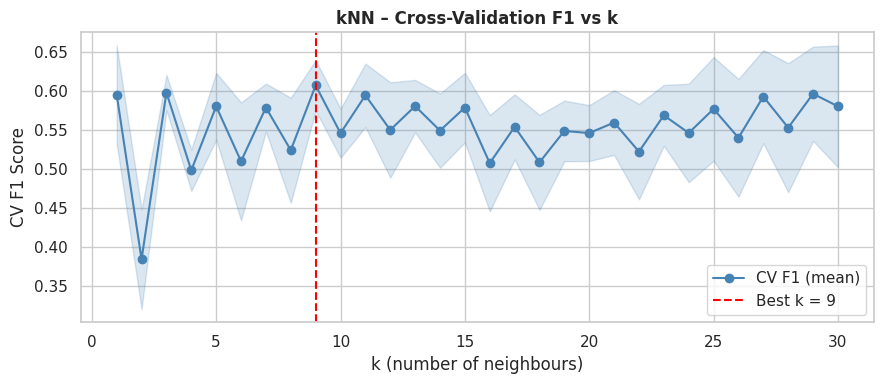

In [22]:
# ── Tune k via 5-fold CV 
k_values  = range(1, 31)
cv_means  = []
cv_stds   = []

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for k in k_values:
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k), X_tr, y_cls_tr,
        cv=kf, scoring='f1')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

best_k   = k_values[np.argmax(cv_means)]
best_cv  = max(cv_means)
print(f'Best k = {best_k}  |  CV F1 = {best_cv:.4f}')

# ── Plot CV curve 
plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_means, marker='o', color='steelblue', label='CV F1 (mean)')
plt.fill_between(k_values,
                 np.array(cv_means) - np.array(cv_stds),
                 np.array(cv_means) + np.array(cv_stds),
                 alpha=0.2, color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k (number of neighbours)')
plt.ylabel('CV F1 Score')
plt.title('kNN – Cross-Validation F1 vs k', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

──────────────────────────────────────────────────
  kNN Classifier (k=9)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Liked       0.60      0.70      0.65        50
       Liked       0.64      0.54      0.59        50

    accuracy                           0.62       100
   macro avg       0.62      0.62      0.62       100
weighted avg       0.62      0.62      0.62       100



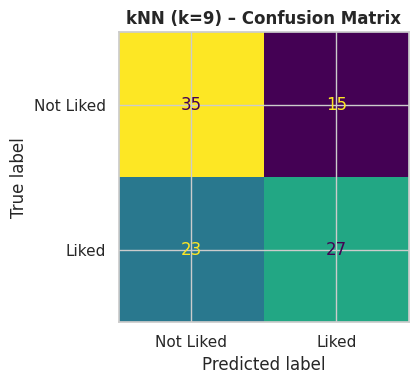

In [23]:
# ── Train final kNN on best k 
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_tr, y_cls_tr)
y_pred_knn = knn.predict(X_te)

print('─' * 50)
print(f'  kNN Classifier (k={best_k})')
print('─' * 50)
print(classification_report(y_cls_te, y_pred_knn, target_names=['Not Liked','Liked']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_cls_te, y_pred_knn),
                       display_labels=['Not Liked','Liked']).plot(ax=ax, colorbar=False)
ax.set_title(f'kNN (k={best_k}) – Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3  Decision Tree Classifier

> *"Split the feature space recursively using information gain / Gini impurity."*  — Week 7c slides

We tune `max_depth` (1–20) with 5-fold CV and visualise the pruned tree and feature importances.

Best max_depth = 4  |  CV F1 = 0.5551


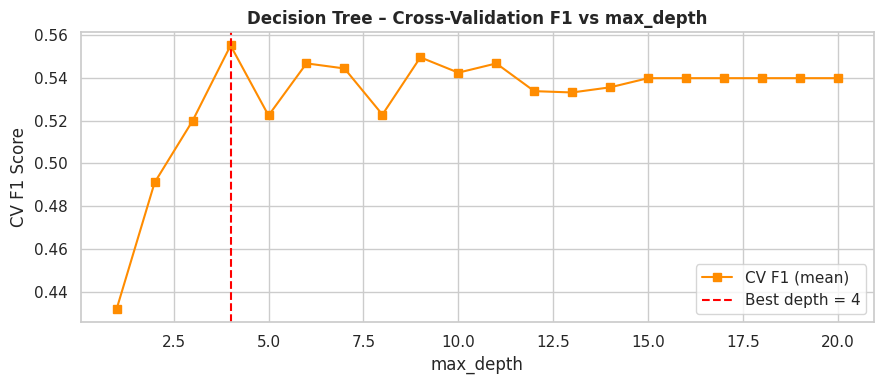

In [24]:
# ── Tune max_depth 
depths    = range(1, 21)
dt_cv_f1  = []

for d in depths:
    scores = cross_val_score(
        DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
        X_tr, y_cls_tr, cv=kf, scoring='f1')
    dt_cv_f1.append(scores.mean())

best_depth = depths[np.argmax(dt_cv_f1)]
print(f'Best max_depth = {best_depth}  |  CV F1 = {max(dt_cv_f1):.4f}')

plt.figure(figsize=(9, 4))
plt.plot(depths, dt_cv_f1, marker='s', color='darkorange', label='CV F1 (mean)')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('CV F1 Score')
plt.title('Decision Tree – Cross-Validation F1 vs max_depth', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

──────────────────────────────────────────────────
  Decision Tree (max_depth=4)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Liked       0.64      0.60      0.62        50
       Liked       0.62      0.66      0.64        50

    accuracy                           0.63       100
   macro avg       0.63      0.63      0.63       100
weighted avg       0.63      0.63      0.63       100



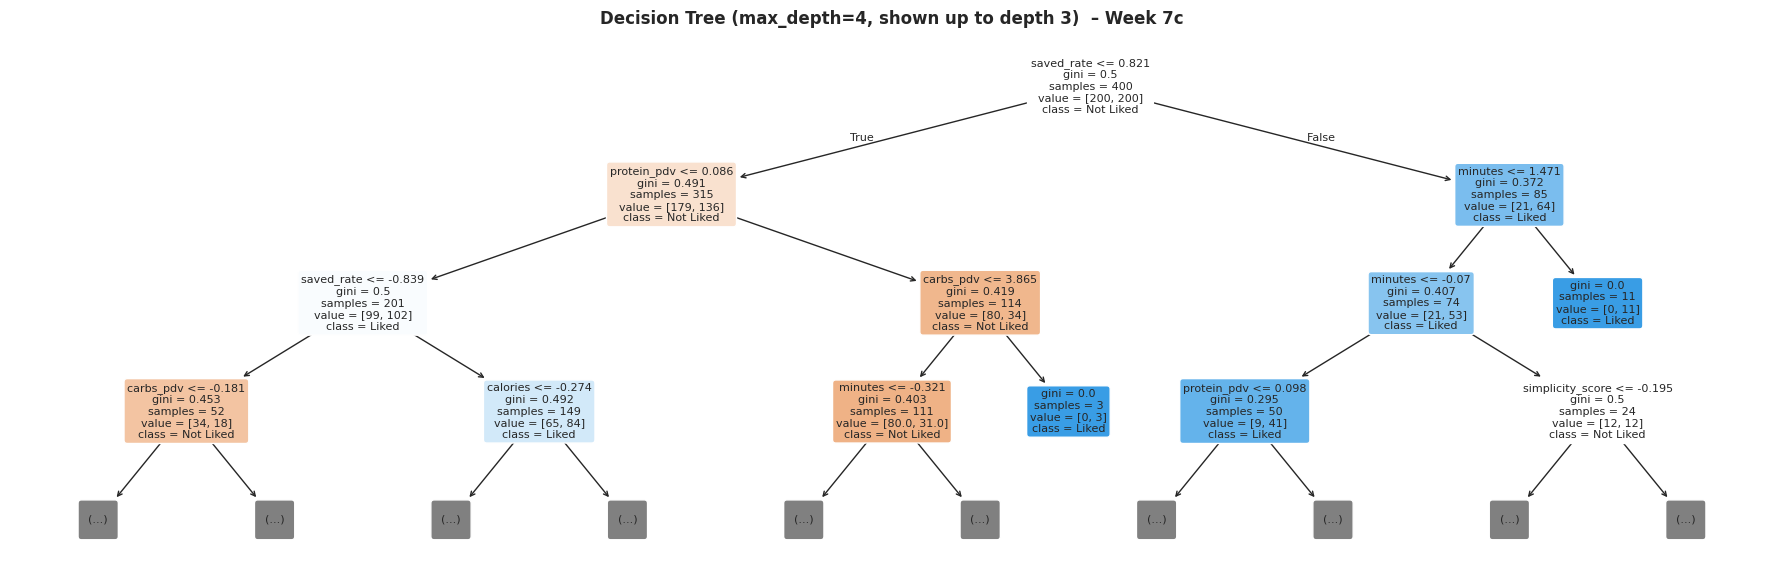

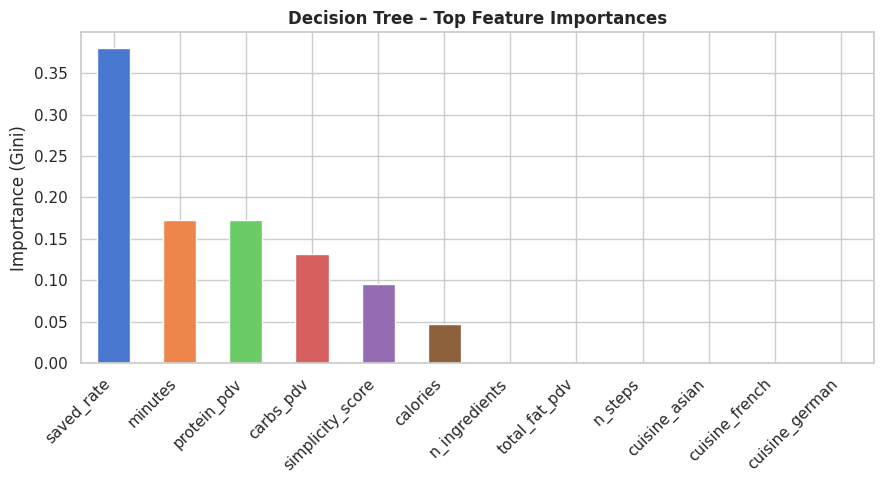

In [25]:
# ── Train final Decision Tree 
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt.fit(X_tr, y_cls_tr)
y_pred_dt = dt.predict(X_te)

print('─' * 50)
print(f'  Decision Tree (max_depth={best_depth})')
print('─' * 50)
print(classification_report(y_cls_te, y_pred_dt, target_names=['Not Liked','Liked']))

# ── Visualise the tree (depth ≤ 3 for readability) 
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(dt, max_depth=3, feature_names=FEATURE_COLS,
          class_names=['Not Liked','Liked'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title(f'Decision Tree (max_depth={best_depth}, shown up to depth 3)  – Week 7c',
             fontweight='bold')
plt.tight_layout()
plt.show()

# ── Feature importances 
importances = pd.Series(dt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top_feat = importances.head(12)

fig, ax = plt.subplots(figsize=(9, 5))
top_feat.plot(kind='bar', ax=ax, color=sns.color_palette('muted'), edgecolor='white')
ax.set_title('Decision Tree – Top Feature Importances', fontweight='bold')
ax.set_ylabel('Importance (Gini)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.4  Logistic Regression

> *"Model the log-odds of the class as a linear combination of features."*  — Week 9a slides

We use L2 regularisation and report the ROC-AUC curve alongside standard metrics.

──────────────────────────────────────────────────
  Logistic Regression  (C=1.0, L2)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

   Not Liked       0.59      0.70      0.64        50
       Liked       0.63      0.52      0.57        50

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100



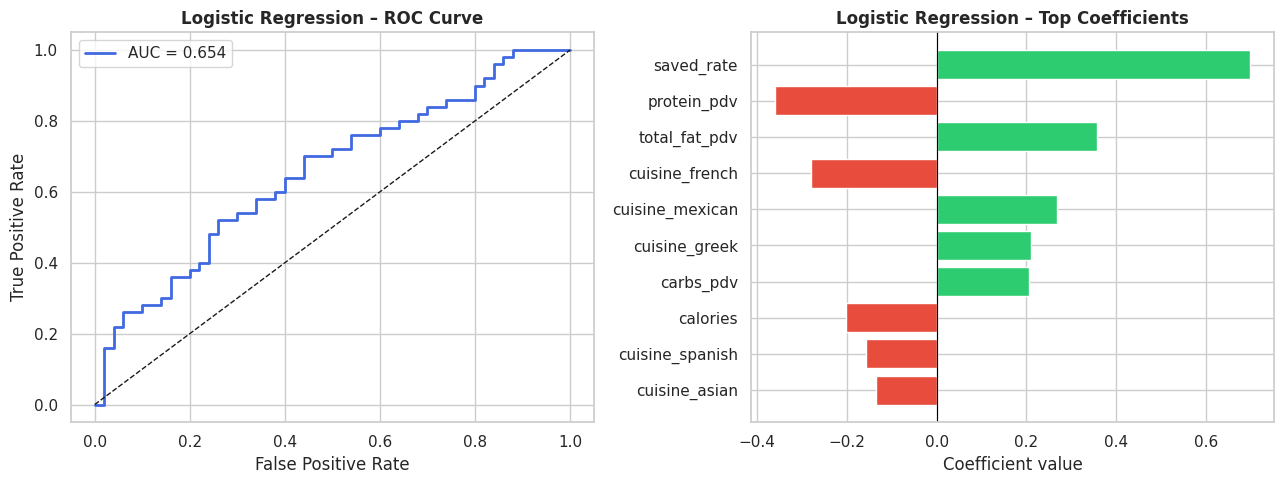

ROC-AUC = 0.6544


In [26]:
# ── Train Logistic Regression 
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs', C=1.0)
lr.fit(X_tr, y_cls_tr)
y_pred_lr   = lr.predict(X_te)
y_prob_lr   = lr.predict_proba(X_te)[:, 1]

print('─' * 50)
print('  Logistic Regression  (C=1.0, L2)')
print('─' * 50)
print(classification_report(y_cls_te, y_pred_lr, target_names=['Not Liked','Liked']))

# ── ROC curve 
fpr, tpr, _ = roc_curve(y_cls_te, y_prob_lr)
auc_score   = roc_auc_score(y_cls_te, y_prob_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='royalblue', lw=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Logistic Regression – ROC Curve', fontweight='bold')
axes[0].legend()

# Top-10 feature coefficients
coef_series = pd.Series(lr.coef_[0], index=FEATURE_COLS)
top_coef    = coef_series.abs().sort_values(ascending=False).head(10)
coef_vals   = coef_series[top_coef.index]

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in coef_vals]
axes[1].barh(coef_vals.index[::-1], coef_vals.values[::-1], color=colors[::-1], edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Logistic Regression – Top Coefficients', fontweight='bold')
axes[1].set_xlabel('Coefficient value')

plt.tight_layout()
plt.show()
print(f'ROC-AUC = {auc_score:.4f}')

### 7.5  Classification Model Comparison

Side-by-side comparison of kNN, Decision Tree, and Logistic Regression across four metrics — following Week 8c (Model Evaluation).

,Accuracy,Precision,Recall,F1 Score
Model,,,,
kNN (k=9),0.62,0.6429,0.54,0.5870
Decision Tree (d=4),0.63,0.6226,0.66,0.6408
Logistic Regression,0.61,0.6341,0.52,0.5714


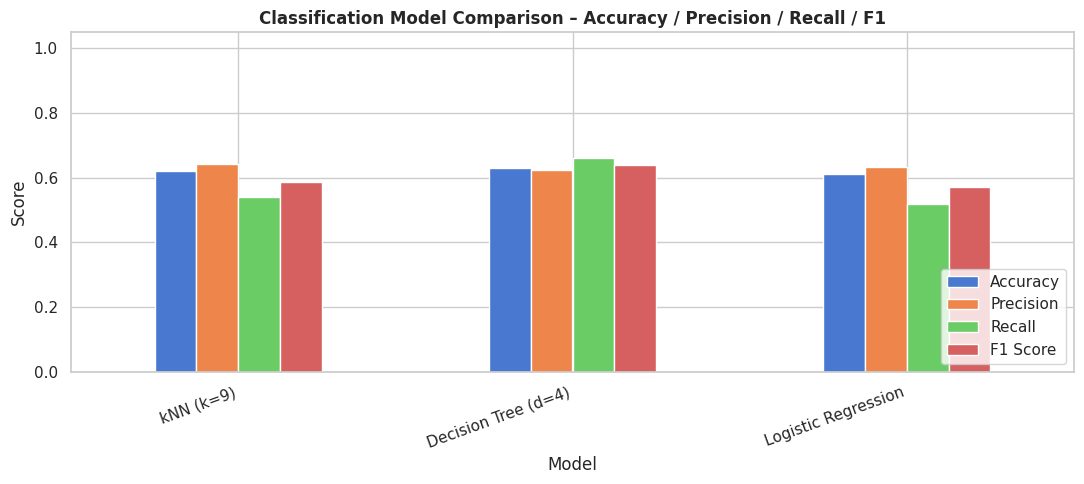


✅ Best model by F1: Decision Tree (d=4)  (0.6408)


In [27]:
# ── Collect all metrics 
models = {
    f'kNN (k={best_k})':             y_pred_knn,
    f'Decision Tree (d={best_depth})': y_pred_dt,
    'Logistic Regression':           y_pred_lr,
}

rows = []
for name, y_pred in models.items():
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_cls_te, y_pred),
        'Precision': precision_score(y_cls_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_cls_te, y_pred, zero_division=0),
        'F1 Score':  f1_score(y_cls_te, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(rows).set_index('Model')
display(results_df.round(4))

# ── Bar chart comparison 
fig, ax = plt.subplots(figsize=(11, 5))
results_df.plot(kind='bar', ax=ax, edgecolor='white',
                color=sns.color_palette('muted', 4))
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison – Accuracy / Precision / Recall / F1',
             fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model = results_df['F1 Score'].idxmax()
print(f'\n✅ Best model by F1: {best_model}  ({results_df.loc[best_model, "F1 Score"]:.4f})')

### 7.6  Linear Regression – Predicting Average Rating

> *"Model the relationship between features and a continuous target."*  — Week 9c slides

We predict the numeric `avg_rating` instead of the binary liked label and evaluate with RMSE and R².

──────────────────────────────────────────────────
  Linear Regression – Predicting avg_rating
──────────────────────────────────────────────────
  RMSE : 0.1682
  R²   : 0.1692


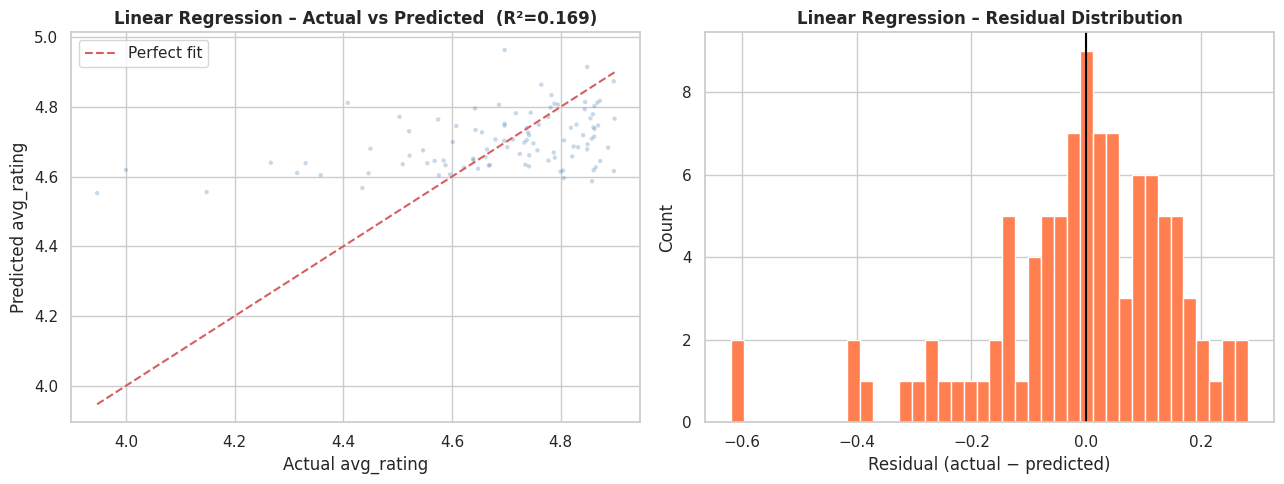

In [28]:
# ── Train Linear Regression 
lin_reg = LinearRegression()
lin_reg.fit(X_tr, y_reg_tr)
y_pred_linreg = lin_reg.predict(X_te)

rmse = np.sqrt(mean_squared_error(y_reg_te, y_pred_linreg))
r2   = r2_score(y_reg_te, y_pred_linreg)

print('─' * 50)
print('  Linear Regression – Predicting avg_rating')
print('─' * 50)
print(f'  RMSE : {rmse:.4f}')
print(f'  R²   : {r2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs Actual scatter
axes[0].scatter(y_reg_te, y_pred_linreg, alpha=0.3, color='steelblue', edgecolor='none', s=10)
mn, mx = y_reg_te.min(), y_reg_te.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual avg_rating')
axes[0].set_ylabel('Predicted avg_rating')
axes[0].set_title(f'Linear Regression – Actual vs Predicted  (R²={r2:.3f})', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_reg_te - y_pred_linreg
axes[1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_xlabel('Residual (actual − predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Linear Regression – Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

### 7.7  K-Means Clustering

> *"Partition recipes into groups of similar nutritional and complexity profiles."*  — Week 11a slides

We use the **Elbow Method** (inertia) to choose k and then profile each cluster.

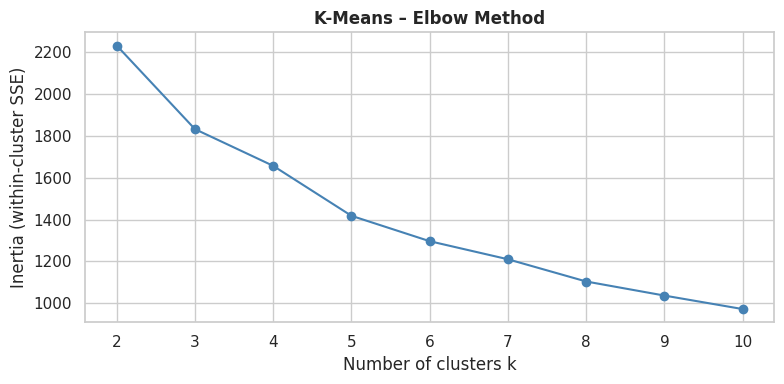

In [29]:
# ── Elbow method 
# Use only the core numeric features (no cuisine dummies) for clustering
CLUSTER_FEATURES = ['minutes', 'n_steps', 'n_ingredients',
                    'calories', 'simplicity_score', 'saved_rate']

X_clust = scaler.fit_transform(df_ml[CLUSTER_FEATURES].values)

inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia (within-cluster SSE)')
plt.title('K-Means – Elbow Method', fontweight='bold')
plt.tight_layout()
plt.show()

Cluster profiles (mean values):


,minutes,n_steps,n_ingredients,calories,simplicity_score,saved_rate,avg_rating,liked
cluster,,,,,,,,
0,42.14,7.52,6.74,368.53,0.86,0.33,4.66,0.39
1,549.66,8.74,10.06,465.01,0.51,0.44,4.64,0.42
2,86.25,15.15,13.21,641.00,0.69,0.46,4.73,0.51
3,54.01,9.57,9.13,296.58,0.80,0.44,4.76,0.62


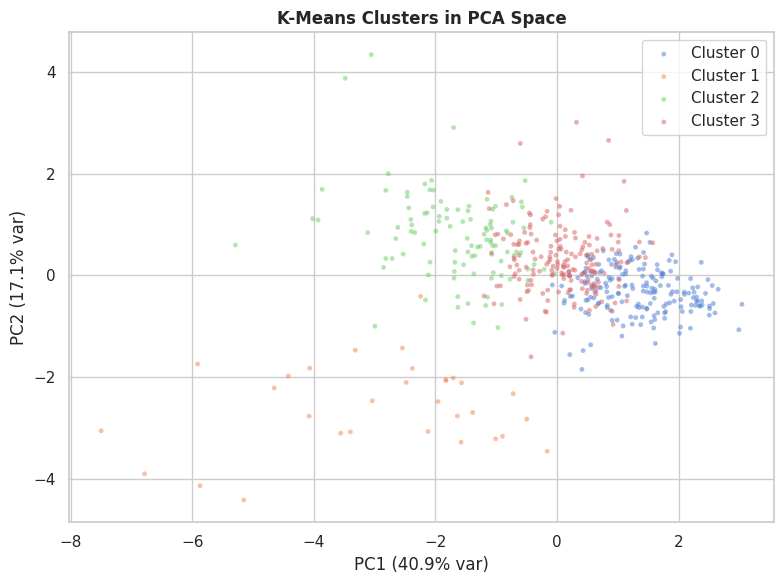

In [30]:
# ── Fit final K-Means (choose k=4 — adjust if elbow differs) 
BEST_K_MEANS = 4   # change this if the elbow plot suggests otherwise

km_final = KMeans(n_clusters=BEST_K_MEANS, random_state=RANDOM_STATE, n_init='auto')
df_ml['cluster'] = km_final.fit_predict(X_clust)

# ── Cluster profiles 
cluster_profile = df_ml.groupby('cluster')[CLUSTER_FEATURES + ['avg_rating', 'liked']].mean().round(2)
print('Cluster profiles (mean values):')
display(cluster_profile)

# ── Visualise clusters with PCA (2-D projection) 
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_clust)

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette('muted', BEST_K_MEANS)
for c in range(BEST_K_MEANS):
    mask = df_ml['cluster'] == c
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               s=12, alpha=0.5, color=palette[c], label=f'Cluster {c}', edgecolor='none')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('K-Means Clusters in PCA Space', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.8  PCA – Dimensionality Reduction & Visualisation

> *"Project high-dimensional data onto orthogonal axes of maximum variance."*  — Recitation 11

We examine the scree plot (explained variance) and then project the dataset into 2-D coloured by `liked`.

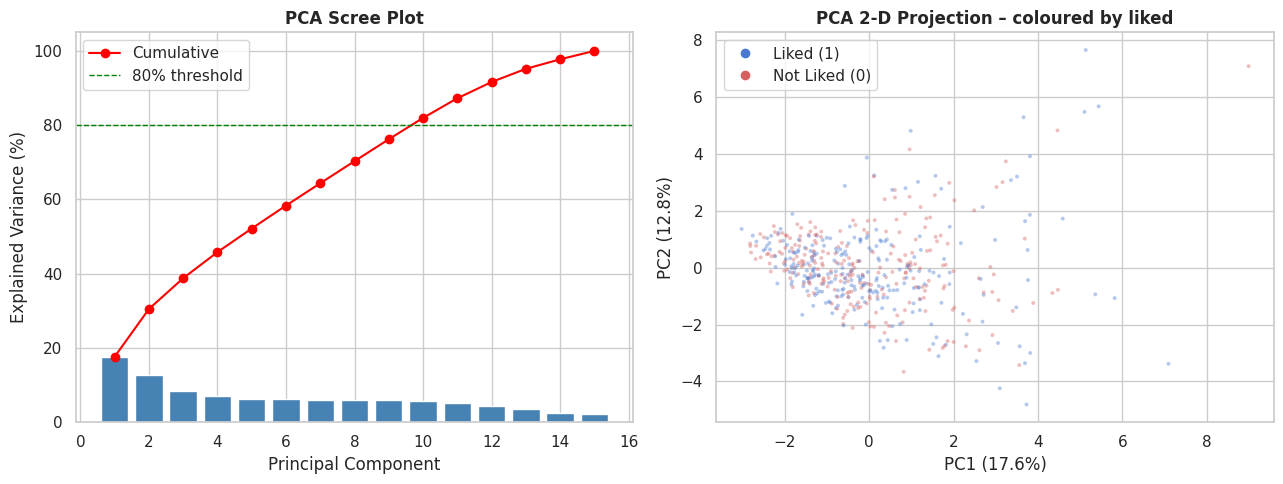

Components needed to reach 90% explained variance: 12


In [31]:
# ── Full PCA on all features 
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, min(16, len(evr)+1)), evr[:15] * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, min(16, len(evr)+1)), cumvar[:15] * 100,
             marker='o', color='red', label='Cumulative')
axes[0].axhline(80, color='green', linestyle='--', lw=1, label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Scree Plot', fontweight='bold')
axes[0].legend()

# 2-D PCA scatter coloured by liked
pca2_all = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2_all.fit_transform(X_scaled)

colors_cls = [sns.color_palette('muted')[0] if l else sns.color_palette('muted')[3] for l in y_cls]
axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                c=colors_cls, s=8, alpha=0.4, edgecolor='none')
liked_patch    = plt.Line2D([0],[0], marker='o', color='w',
                            markerfacecolor=sns.color_palette('muted')[0], label='Liked (1)', markersize=8)
not_liked_patch = plt.Line2D([0],[0], marker='o', color='w',
                             markerfacecolor=sns.color_palette('muted')[3], label='Not Liked (0)', markersize=8)
axes[1].legend(handles=[liked_patch, not_liked_patch])
axes[1].set_xlabel(f'PC1 ({pca2_all.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2_all.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA 2-D Projection – coloured by liked', fontweight='bold')

plt.tight_layout()
plt.show()

n_90 = np.searchsorted(cumvar, 0.90) + 1
print(f'Components needed to reach 90% explained variance: {n_90}')

### 7.9  ML Summary

| Method | Task | Key metric |
|---|---|---|
| kNN | Classification (liked) | See results_df |
| Decision Tree | Classification (liked) | See results_df |
| Logistic Regression | Classification (liked) | See results_df |
| Linear Regression | Regression (avg_rating) | RMSE & R² |
| K-Means | Clustering (4 clusters) | Elbow inertia |
| PCA | Visualisation / compression | Scree plot |

**Key takeaways:**
- The best classifier (by F1) is shown automatically in the model comparison cell.
- Linear regression shows a low R² — recipe popularity is hard to predict from nutritional data alone, suggesting behavioural or textual features would help.
- K-Means reveals distinct recipe archetypes (quick/simple vs complex/hearty etc.).
- PCA shows moderate class separation in 2-D, confirming that the features carry *some* signal about popularity.